# Memory — Address Decoding, Cells, and Arrays

A memory is a grid of storage cells addressed by a decoder. This notebook draws the **SRAM cell**, shows how an **address decoder selects one word line** (reusing the decoder block), and builds an interactive **RAM/ROM array** where you can read and write and watch the addressed cell light up.

$$\text{word line } i \text{ active} \iff \text{address} = i$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import ipywidgets as widgets
from IPython.display import display
%matplotlib inline

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'font.size':9})
ON, OFF='#c0392b','#b0b0b0'
def wcol(b): return ON if b else OFF
def wlw(b):  return 2.4 if b else 1.1
print('primitives ready')


primitives ready


## The 6T SRAM Cell — Two Cross-Coupled Inverters

A static RAM bit is held by two inverters in a loop (the same cross-coupling idea as the latch), accessed through two pass transistors gated by the word line. When the word line is high the bit line connects to the stored value for read or write. The schematic lights the stored state and the access path.


In [2]:
def sram_cell(stored, word_line, bit_line, writing):
    q = bit_line if (word_line and writing) else stored
    qb = 1-q
    fig,ax=plt.subplots(figsize=(7,3.8)); ax.set_xlim(0,9); ax.set_ylim(0,5); ax.axis('off')
    # two inverters as triangles
    for (x,val,lab) in [(3.2,q,'Q'),(5.0,qb,'Q\u0305')]:
        ax.add_patch(plt.Polygon([(x,2.0),(x,3.0),(x+0.7,2.5)],closed=True,fc='#eef2f7',ec='#34495e',lw=1.4,zorder=2))
        ax.scatter([x+0.9],[2.5],s=30,color=wcol(val),zorder=3)
        ax.text(x+0.35,3.3,lab+f'={val}',ha='center',color=wcol(val),fontsize=9,weight='bold')
    # cross-couple feedback
    ax.annotate('',xy=(3.2,2.7),xytext=(5.9,2.3),arrowprops=dict(arrowstyle='->',color=wcol(qb),lw=wlw(qb),connectionstyle='arc3,rad=0.5'))
    ax.annotate('',xy=(5.0,2.3),xytext=(4.1,2.7),arrowprops=dict(arrowstyle='->',color=wcol(q),lw=wlw(q),connectionstyle='arc3,rad=0.5'))
    # word line
    ax.plot([1.0,8.0],[4.2,4.2],color=wcol(word_line),lw=wlw(word_line))
    ax.text(0.7,4.2,f'WL={word_line}',ha='right',color=wcol(word_line),fontsize=9,weight='bold')
    # access transistors (pass gates)
    for (x,bl,node) in [(2.2,bit_line,q),(6.4,1-bit_line,qb)]:
        gate_on=word_line
        ax.add_patch(Rectangle((x-0.2,2.3),0.4,0.4,fc='#fdf0e6' if gate_on else '#eee',ec='#e67e22' if gate_on else '#bbb',lw=1.3,zorder=2))
        ax.plot([x,x],[2.7,4.2],color=wcol(word_line),lw=1.0)
        ax.plot([x,x],[1.4,2.3],color=wcol(bl) if gate_on else '#ddd',lw=wlw(bl) if gate_on else 1.0)
    ax.text(2.2,1.1,f'BL={bit_line}',ha='center',fontsize=8,color=wcol(bit_line))
    ax.text(6.4,1.1,f'BL\u0305={1-bit_line}',ha='center',fontsize=8,color=wcol(1-bit_line))
    mode = ('WRITE' if writing else 'READ') if word_line else 'IDLE (holding)'
    ax.set_title(f'6T SRAM cell  --  {mode},  stored bit Q={q}',fontsize=10,
                 color='#e67e22' if word_line else '#7f8c8d')
    plt.tight_layout(); plt.show()
w_st=widgets.ToggleButtons(options=[0,1],value=1,description='stored:')
w_wl=widgets.ToggleButtons(options=[0,1],value=1,description='word line:')
w_bl=widgets.ToggleButtons(options=[0,1],value=0,description='bit line:')
w_wr=widgets.ToggleButtons(options=[0,1],value=1,description='writing:')
display(widgets.VBox([w_st,w_wl,w_bl,w_wr]),
        widgets.interactive_output(sram_cell,{'stored':w_st,'word_line':w_wl,'bit_line':w_bl,'writing':w_wr}))


Output()

## Address Decoding — One Word Line at a Time

The address bus drives a decoder; the decoder asserts exactly one word line, selecting the row to access. This is the decoder block from the MSI notebook doing real work. Change the address and watch the selected word line light up.


In [3]:
def address_decode(nbits, addr):
    N=2**nbits; addr%=N
    fig,ax=plt.subplots(figsize=(7,0.5*N+1.5)); ax.set_xlim(0,8); ax.set_ylim(0,N+1); ax.axis('off')
    ax.add_patch(Rectangle((2.2,0.6),1.6,N,fc='#eef2f7',ec='#34495e',lw=1.6,zorder=2))
    ax.text(3.0,0.6+N/2,f'{nbits}:{N}\ndecoder',ha='center',va='center',fontsize=8.5,weight='bold',zorder=3)
    sbits=[(addr>>b)&1 for b in range(nbits)]
    for b in range(nbits):
        yy=0.6+N-(b+1)*N/(nbits+1)
        ax.scatter([1.0],[yy],s=34,color=wcol(sbits[nbits-1-b]),zorder=4)
        ax.text(0.7,yy,f'A{nbits-1-b}={sbits[nbits-1-b]}',ha='right',va='center',color=wcol(sbits[nbits-1-b]),fontsize=9,weight='bold')
        ax.plot([1.0,2.2],[yy,yy],color=wcol(sbits[nbits-1-b]),lw=wlw(sbits[nbits-1-b]),zorder=1)
    for i in range(N):
        yy=0.6+N-(i+0.5)*N/N; active=int(i==addr)
        ax.plot([3.8,6.2],[yy,yy],color=wcol(active),lw=wlw(active),zorder=1)
        ax.text(6.4,yy,f'WL{i}'+('  <- selected' if active else ''),ha='left',va='center',
                color=wcol(active),fontsize=9,weight='bold' if active else 'normal')
    ax.set_title(f'address {addr} ({format(addr,f"0{nbits}b")}) selects word line {addr}',fontsize=10)
    plt.tight_layout(); plt.show()
w_nb=widgets.IntSlider(value=3,min=2,max=4,description='addr bits:')
w_ad=widgets.IntSlider(value=0,min=0,max=15,description='address:')
display(widgets.VBox([w_nb,w_ad]),widgets.interactive_output(address_decode,{'nbits':w_nb,'addr':w_ad}))


Output()

## RAM Array — Read and Write

A full RAM is a grid: rows selected by the address decoder, columns are the data bits of each word. Use the controls to write a value to an address, then read it back. The addressed word lights up and the contents grid updates — the state persists across operations in this session.


In [4]:
# session-persistent memory contents
_RAM = {'mem': [0]*8, 'last': None}
def ram_op(addr, data, operation):
    mem=_RAM['mem']
    if operation=='write':
        mem[addr]=data; _RAM['last']=('W',addr,data)
        read_val=data
    else:
        read_val=mem[addr]; _RAM['last']=('R',addr,read_val)
    N=len(mem); width=4
    fig,ax=plt.subplots(figsize=(7,4)); ax.set_xlim(0,width+4); ax.set_ylim(0,N+1); ax.axis('off')
    ax.text(2.5,N+0.6,'address',ha='center',fontsize=9,weight='bold')
    ax.text(width+2.0,N+0.6,'data (4-bit)',ha='center',fontsize=9,weight='bold')
    for i in range(N):
        yy=N-i
        sel=int(i==addr)
        ax.add_patch(Rectangle((0.3,yy-0.4),1.6,0.8,fc='#fdecea' if sel else '#f7f9fb',ec='#c0392b' if sel else '#ccc',lw=1.6 if sel else 1.0))
        ax.text(1.1,yy,f'{i}  ({format(i,"03b")})',ha='center',va='center',fontsize=8,color='#c0392b' if sel else '#555',weight='bold' if sel else 'normal')
        bits=[(mem[i]>>b)&1 for b in range(width)][::-1]
        for b in range(width):
            x=width-1-b+2.0
            bit=bits[b]
            ax.add_patch(Rectangle((x,yy-0.35),0.7,0.7,fc=wcol(bit) if sel else ('#34495e' if bit else '#eee'),ec='#333',lw=1.0))
            ax.text(x+0.35,yy,str(bit),ha='center',va='center',fontsize=9,color='white' if (bit or sel) else '#999',weight='bold')
        ax.text(width+3.0,yy,f'={mem[i]}',ha='left',va='center',fontsize=8,color='#555')
    op,ad,vl=_RAM['last']
    ax.set_title(f'{"WROTE" if op=="W" else "READ"} value {vl} at address {ad}',fontsize=10,
                 color='#e67e22' if op=='W' else '#2471a3')
    plt.tight_layout(); plt.show()
w_ra=widgets.IntSlider(value=0,min=0,max=7,description='address:')
w_rd=widgets.IntSlider(value=5,min=0,max=15,description='data:')
w_op=widgets.ToggleButtons(options=['write','read'],value='write',description='op:')
display(widgets.VBox([w_ra,w_rd,w_op]),
        widgets.interactive_output(ram_op,{'addr':w_ra,'data':w_rd,'operation':w_op}))


Output()

## ROM — A Hard-Wired Lookup Table

A ROM stores fixed data: the address indexes a permanent word. It is exactly a truth table cast into silicon, often used for microcode or character maps. Below, a ROM is preloaded with the squares $0^2,1^2,\dots$; addressing it returns the stored value with no write possible.


In [5]:
def rom_lookup(addr):
    ROM=[(i*i) & 0xFF for i in range(8)]   # squares, fixed
    val=ROM[addr]
    fig,ax=plt.subplots(figsize=(7,3.6)); ax.set_xlim(0,9); ax.set_ylim(0,9); ax.axis('off')
    for i in range(8):
        yy=8-i; sel=int(i==addr)
        ax.add_patch(Rectangle((0.5,yy-0.4),2.0,0.8,fc='#fdecea' if sel else '#f7f9fb',ec='#c0392b' if sel else '#ccc',lw=1.5 if sel else 1.0))
        ax.text(1.5,yy,f'addr {i} -> {ROM[i]}',ha='center',va='center',fontsize=9,
                color='#c0392b' if sel else '#555',weight='bold' if sel else 'normal')
    ax.annotate('',xy=(4.5,8-addr),xytext=(2.7,8-addr),arrowprops=dict(arrowstyle='->',color='#c0392b',lw=2))
    ax.text(5.0,8-addr,f'data out = {val}',fontsize=11,color='#c0392b',weight='bold',va='center')
    ax.set_title(f'ROM (squares table)  --  addr {addr} returns {addr}\u00b2={val}',fontsize=10)
    plt.tight_layout(); plt.show()
w_roa=widgets.IntSlider(value=3,min=0,max=7,description='address:')
display(w_roa,widgets.interactive_output(rom_lookup,{'addr':w_roa}))


IntSlider(value=3, description='address:', max=7)

Output()

## Read and Write Timing

A write asserts address, data, and the write-enable; a read asserts address and read-enable and the data appears after the access time. The waveform shows a write to an address followed by a read of the same address returning the value.


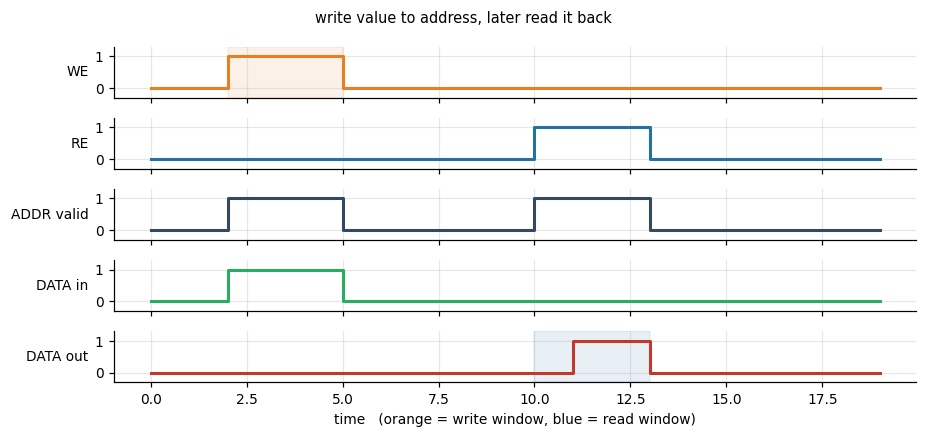

In [6]:
def mem_timing():
    t=np.arange(20)
    WE=np.zeros(20); WE[2:5]=1
    RE=np.zeros(20); RE[10:13]=1
    ADDR=np.zeros(20); ADDR[2:5]=1; ADDR[10:13]=1   # same address asserted
    DATA=np.zeros(20); DATA[2:5]=1                    # write data
    DOUT=np.zeros(20); DOUT[11:13]=1                  # read returns it (after access time)
    sigs=[(WE,'WE','#e67e22'),(RE,'RE','#2471a3'),(ADDR,'ADDR valid','#34495e'),
          (DATA,'DATA in','#27ae60'),(DOUT,'DATA out','#c0392b')]
    fig,axes=plt.subplots(len(sigs),1,figsize=(8.5,4),sharex=True)
    for ax,(s,lab,c) in zip(axes,sigs):
        ax.step(t,s,where='post',color=c,lw=2); ax.set_ylim(-0.3,1.3); ax.set_yticks([0,1])
        ax.set_ylabel(lab,rotation=0,ha='right',va='center'); ax.grid(True,alpha=0.3)
    axes[0].axvspan(2,5,color='#e67e22',alpha=0.1); axes[-1].axvspan(10,13,color='#2471a3',alpha=0.1)
    axes[-1].set_xlabel('time   (orange = write window, blue = read window)')
    fig.suptitle('write value to address, later read it back',fontsize=9.5)
    plt.tight_layout(); plt.show()
mem_timing()
